# Localizing Particles using LodeSTAR

<div style="background-color: #f0f8ff; border: 2px solid #4682b4; padding: 10px;">
<a href="https://colab.research.google.com/github/DeepTrackAI/DeepLearningCrashCourse/blob/main/Ch06_SelfSupervised/ec06_1_lodestar/lodestar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
<strong>If using Colab/Kaggle:</strong> You need to uncomment the code in the cell below this one.
</div>

In [202]:
# !pip install deeplay deeptrack  # Uncomment if using Colab/Kaggle.

This notebook provides you with a complete code example that demonstrates how to train and use LodeSTAR to localize particles.

<div style="background-color: #f0f8ff; border: 2px solid #4682b4; padding: 10px;">
<strong>Note:</strong> This notebook contains the Code Example 6-1 from the book  

**Deep Learning Crash Course**  
Giovanni Volpe, Benjamin Midtvedt, Jesús Pineda, Henrik Klein Moberg, Harshith Bachimanchi, Joana B. Pereira, Carlo Manzo  
No Starch Press, San Francisco (CA), 2026  
ISBN-13: 9781718503922  

[https://nostarch.com/deep-learning-crash-course](https://nostarch.com/deep-learning-crash-course)

You can find the other notebooks on the [Deep Learning Crash Course GitHub page](https://github.com/DeepTrackAI/DeepLearningCrashCourse).
</div>

## Creating the Dataset

Define a particle located near the center of the image ...

In [203]:
import deeptrack as dt
from numpy.random import uniform

image_size = 51

particle = dt.PointParticle(
    position=lambda: uniform(image_size / 2 - 5, image_size / 2 + 5, size=2),
)

... define the optical system as a fluorescence microscope ...

In [204]:
optics = dt.Fluorescence(output_region=(0, 0, image_size, image_size))

... create the  simulation pipeline ...

In [205]:
import torch

simulation = (optics(particle) >> dt.NormalizeMinMax()
              >> dt.Gaussian(sigma=0.1) >> dt.MoveAxis(-1, 0)
              >> dt.pytorch.ToTensor(dtype=torch.float32))

... create the train and test datasets ...

In [206]:
train_dataset = dt.pytorch.Dataset(simulation, length=100)
test_dataset = dt.pytorch.Dataset(simulation & particle.position, length=5000)

... and plot some generated particles and their position.

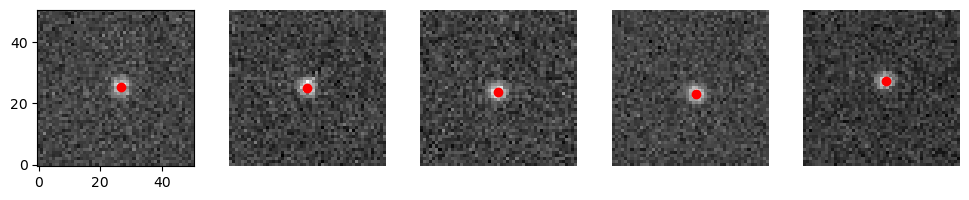

In [207]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axs):
    image, position = test_dataset[i]
    ax.imshow(image[0], cmap="gray", origin="lower")
    ax.scatter(position[1], position[0], c="r")
    if i != 0: ax.axis("off")
plt.tight_layout()
plt.show()

## Learning from Translations

Implement a neural network with a convolutional backbone and a dense top layer ...

In [208]:
import deeplay as dl

backbone = dl.ConvolutionalNeuralNetwork(
    in_channels=1, hidden_channels=[16, 32, 64], out_channels=128,
    pool=torch.nn.MaxPool2d(2),
)
model = dl.Sequential(backbone, torch.nn.Flatten(), torch.nn.LazyLinear(2))

... implement a function to translate the input image ...

In [209]:
from kornia.geometry.transform import translate

def image_translation(batch, translation):
    """Translate a batch of images."""
    xy_flipped_translation = translation[:, [1, 0]]
    return translate(batch, xy_flipped_translation, padding_mode="reflection")

... a function to translate back the output positions ...

In [210]:
def inverse_translation(preds, applied_translation):
    """Invert translation of predicted positions."""
    return preds - applied_translation

... and a class to implement a self-supervised particle localizer trained with translations ...

In [211]:
from torch import rand

class ParticleLocalizer(dl.Application):
    """LodeSTAR implementation with translations."""

    def __init__(self, model, n_transforms=8, **kwargs):
        """Initialize the ParticleLocalizer."""
        self.model, self.n_transforms = model, n_transforms
        super().__init__(**kwargs)

    def forward(self, batch):
        """Forward pass through the model."""
        return self.model(batch)

    def random_arguments(self):
        """Generate random arguments for transformations."""
        return {"translation": \
            (rand(self.n_transforms, 2).float().to(self.device) * 5 - 2.5)}

    def forward_transform(self, batch, translation):
        """Apply forward translation to the image."""
        return image_translation(batch, translation)

    def inverse_transform(self, preds, translation):
        """Apply inverse translation to the predictions."""
        return inverse_translation(preds, translation)

    def training_step(self, image, batch_idx):
        """Perform a single training step."""
        image, *_ = image
        batch = image.repeat(self.n_transforms, 1, 1, 1)

        kwargs = self.random_arguments()
        transformed_batch = self.forward_transform(batch, **kwargs)

        pred_position = self(transformed_batch)
        pred_position = self.inverse_transform(pred_position, **kwargs)

        average_pred_position = pred_position \
            .mean(dim=0, keepdim=True).repeat(self.n_transforms, 1)
        loss = self.loss(pred_position, average_pred_position)
        self.log("loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        return loss

... instantiate this class ...

In [212]:
localizer = ParticleLocalizer(
    model, n_transforms=8, loss=torch.nn.L1Loss(), optimizer=dl.Adam(lr=5e-4),
).create()

... and train the self-supervised particle localizer trained with translations.

In [213]:
dataloader = dl.DataLoader(train_dataset, batch_size=1, shuffle=True)
# trainer = dl.Trainer(max_epochs=100)
# trainer.fit(localizer, dataloader)

### Evaluating the Performance

Evaluate the performance of the self-supervised particle localizer trained with translations ...

In [214]:
images, positions = zip(*test_dataset)
images, positions = torch.stack(images), torch.stack(positions)

# predictions = localizer(images).detach().numpy()

... implement a function to plot the predicted positions versus the real ones ...

In [215]:
def plot_position_comparison(positions, predictions):
    """Plot comparison between predicted and real particle positions."""
    plt.figure(figsize=(14, 8))
    grid = plt.GridSpec(4, 7, wspace=.2, hspace=.1)

    plt.subplot(grid[1:, :3])
    plt.scatter(positions[:, 0], predictions[:, 0], alpha=.5)
    plt.axline((25, 25), slope=1, color="black")
    plt.xlabel("True Horizontal Position", fontsize=20)
    plt.ylabel("Predicted Horizontal Position", fontsize=20)
    plt.axis("equal")

    plt.subplot(grid[1:, 4:])
    plt.scatter(positions[:, 1], predictions[:, 1], alpha=.5)
    plt.axline((25, 25), slope=1, color="black")
    plt.xlabel("True Vertical Position", fontsize=20)
    plt.ylabel("Predicted Vertical Position", fontsize=20)
    plt.axis("equal")

    plt.show()

... and use it to plot the predicted versus real positions.

In [216]:
# plot_position_comparison(positions, predictions)

## Improving the Predictions Averaging Reflected Images

Correct the bias of a self-supervised particle localizer trained with translations.

In [217]:
# direct_preds = localizer(images).detach().numpy()

# flipped_images = images.flip(dims=(2, 3))
# flipped_preds = localizer(flipped_images).detach().numpy()

# predictions_with_difference = ((direct_preds - flipped_preds) / 2
#                                + image_size / 2 - 0.5)

# plot_position_comparison(positions, predictions_with_difference)

## Learning from Reflections

Implement a function to conditionally reflect images along a specified dimension ...

In [218]:
def flip_transform(batch, should_flip, dim):
    """Conditionally flip batch along a specified dimension."""
    should_flip = should_flip.view(-1, 1, 1, 1)
    return torch.where(should_flip, batch.flip(dims=(dim,)), batch)

In [316]:
from torchvision.transforms.functional import rotate
import kornia

def rotate_transform(batch, angles):
    return torch.stack([kornia.geometry.transform.rotate(img, angle, align_corners=True, padding_mode="reflection") for img, angle in zip(batch, angles)])
    return torch.stack([rotate(img, float(angle)) for img, angle in zip(batch, angles)])

def inverse_rotate_transform(preds, angles):
    inv_angles_rad = torch.tensor([(360-angle) * torch.pi / 180 for angle in angles], dtype=torch.float32)
    cos_angles = torch.cos(inv_angles_rad)
    sin_angles = torch.sin(inv_angles_rad)
    
    rotation_matrices = torch.stack([
        torch.stack([cos_angles, -sin_angles], dim=1),
        torch.stack([sin_angles, cos_angles], dim=1)
    ], dim=1)
    
    return torch.stack([preds[i] @ rotation_matrices[i].T for i in range(len(preds))])

In [ ]:
# angles = torch.tensor([0, 90, 180, 270, 360], dtype=torch.float32)
# batch = torch.tensor([[1,0],[1,0],[1,0],[1,0],[1,0]], dtype=torch.float32)

# print(inverse_rotate_transform(batch, angles))

tensor([[ 1.0000e+00,  1.7485e-07],
        [ 1.1925e-08, -1.0000e+00],
        [-1.0000e+00, -8.7423e-08],
        [-4.3711e-08,  1.0000e+00],
        [ 1.0000e+00,  0.0000e+00]])


torch.Size([1, 51, 51])
torch.Size([5, 1, 51, 51])


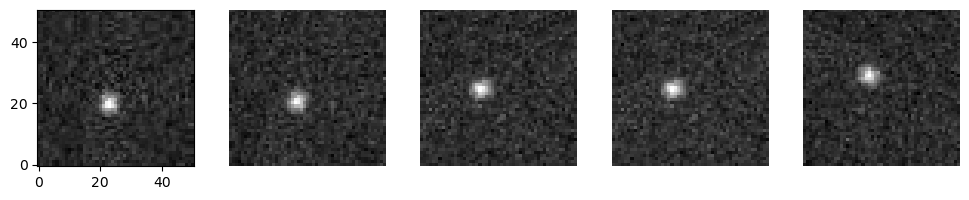

In [318]:
img, position = test_dataset[0]
print(img.shape)

batch = torch.cat([img, img, img, img, img]).unsqueeze(1)


x = 5
translation = (torch.tensor([[x,0],[x,0],[x,0],[x,0],[x,0]]).float())
angles = (360*rand(5)).float()
# angles = torch.tensor([0, 90, 180, 270, 360]).float()


batch = image_translation(batch, translation)
batch = rotate_transform(batch, angles)

print(batch.shape)

fig, axs = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axs):
    image = batch[i]
    ax.imshow(image[0], cmap="gray", origin="lower")
    # ax.scatter(position[1], position[0], c="r")
    if i != 0: ax.axis("off")
plt.tight_layout()
plt.show()


... a function to conditionally inverse flip images ...

In [297]:
def inverse_flip_transform(preds, should_flip, dim):
    """Conditionally inverse flip transformation based on should flip."""
    should_flip_mask = torch.zeros_like(preds).bool()
    should_flip_mask[should_flip, dim] = 1
    return torch.where(should_flip_mask, -preds, preds)

... and a class to implement a self-supervised particle localizer trained also with reflections (flips) ...

In [298]:
class ParticleLocalizerWithFlips(ParticleLocalizer):
    """ParticleLocalizer with additional flips."""

    def forward_transform(self, batch, translation, flip_x, flip_y):
        """Apply forward translations and flips to the batch."""
        batch = image_translation(batch, translation)
        batch = flip_transform(batch, flip_x, dim=3)
        batch = flip_transform(batch, flip_y, dim=2)
        return batch

    def inverse_transform(self, preds, translation, flip_x, flip_y):
        """Apply the inverse transformation to the predictions."""
        preds = inverse_flip_transform(preds, flip_x, dim=1)
        preds = inverse_flip_transform(preds, flip_y, dim=0)
        preds = inverse_translation(preds, translation)
        return preds

    def random_arguments(self):
        """Generate random arguments for translations and flips."""
        return {"translation": \
            (rand(self.n_transforms, 2).float().to(self.device) * 5 - 2.5),
            "flip_x": rand(self.n_transforms).float().to(self.device) > 0.5,
            "flip_y": rand(self.n_transforms).float().to(self.device) > 0.5}

In [299]:
class ParticleLocalizerWithRotations(ParticleLocalizer):
    """ParticleLocalizer with additional flips."""

    def forward_transform(self, batch, translation, rotation):
        """Apply forward translations and flips to the batch."""
        batch = image_translation(batch, translation)
        batch = rotate_transform(batch, rotation)
        return batch

    def inverse_transform(self, preds, translation, rotation):
        """Apply the inverse transformation to the predictions."""
        preds = inverse_rotate_transform(preds, rotation)
        preds = inverse_translation(preds, translation)
        return preds

    def random_arguments(self):
        """Generate random arguments for translations and rotations."""
        return {"translation": \
            (rand(self.n_transforms, 2).float().to(self.device) * 5 - 2.5),
            "rotation": (360*rand(self.n_transforms)).float().to(self.device)}

... train a self-supervised particle localizer with flipping transformations ...

In [300]:
localizer_with_flips = ParticleLocalizerWithFlips(
    model, n_transforms=8, loss=torch.nn.L1Loss(), optimizer=dl.Adam(lr=1e-3),
).create()
trainer_with_flips = dl.Trainer(max_epochs=100)
trainer_with_flips.fit(localizer_with_flips, dataloader)

c:\Users\jojac\anaconda3\envs\stoch\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ Sequential       │ 97.2 K │ train │     0 │
│ 1 │ loss          │ L1Loss           │      0 │ train │     0 │
│ 2 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 3 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 5 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 97.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 97.2 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 23                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\jojac\anaconda3\envs\stoch\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\jojac\anaconda3\envs\stoch\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 99: 100%|██████████| 100/100 [00:00<00:00, 175.69it/s, v_num=39, loss_step=0.0818, loss_epoch=0.0827]


... and plot the predictions versus real positions for a self-supervised particle localizer with reflections.

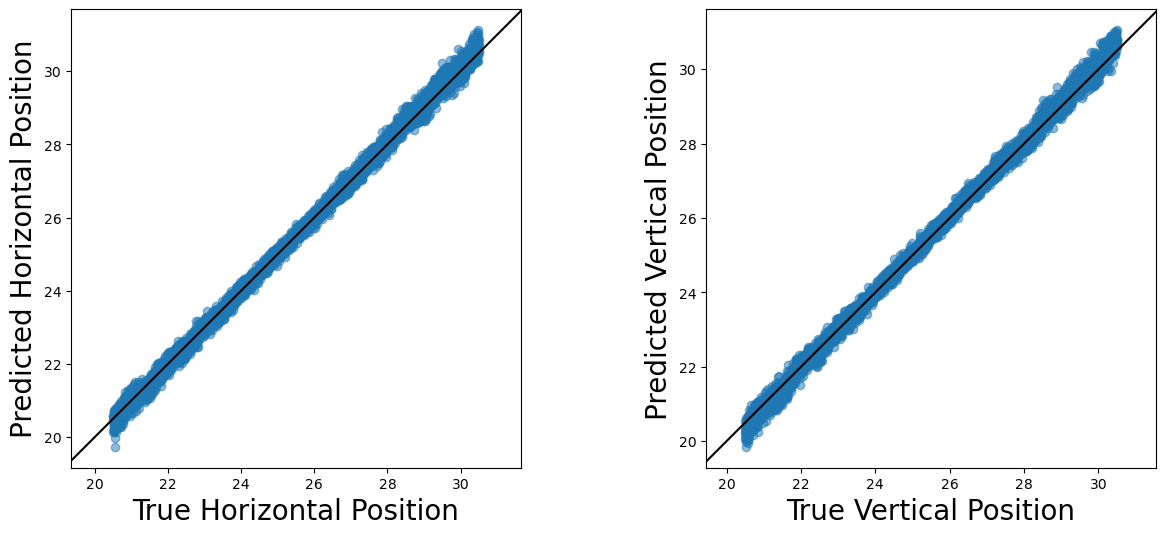

In [301]:
flip_predictions = (localizer_with_flips(images).detach().numpy() 
               + image_size / 2 - 0.5)

plot_position_comparison(positions, flip_predictions)

In [302]:
localizer_with_rotations = ParticleLocalizerWithRotations(
    model, n_transforms=8, loss=torch.nn.L1Loss(), optimizer=dl.Adam(lr=1e-3),
).create()
trainer_with_rotations = dl.Trainer(max_epochs=100)
trainer_with_rotations.fit(localizer_with_rotations, dataloader)

c:\Users\jojac\anaconda3\envs\stoch\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ Sequential       │ 97.2 K │ train │     0 │
│ 1 │ loss          │ L1Loss           │      0 │ train │     0 │
│ 2 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 3 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 5 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 97.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 97.2 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 23                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\jojac\anaconda3\envs\stoch\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\jojac\anaconda3\envs\stoch\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 99: 100%|██████████| 100/100 [00:00<00:00, 103.69it/s, v_num=40, loss_step=0.0744, loss_epoch=0.0655]


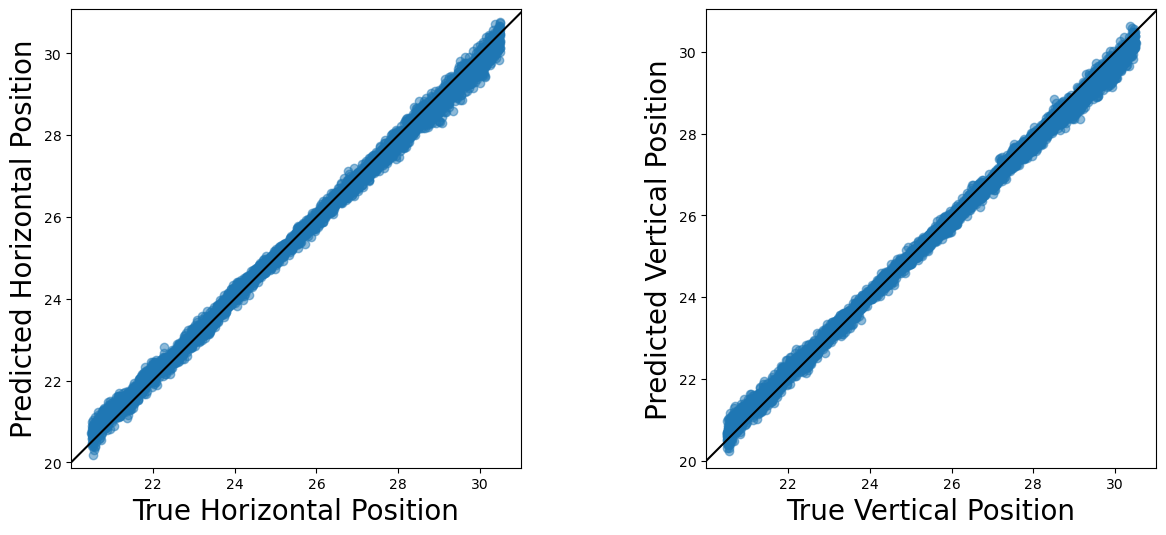

In [303]:
rot_predictions = (localizer_with_rotations(images).detach().numpy() 
               + image_size / 2 - 0.5)

plot_position_comparison(positions, rot_predictions)
# plot_position_comparison(positions, flip_predictions)

## Improving Performance with LodeSTAR

Train LodeSTAR ...

In [304]:
dataloader_lodestar = dl.DataLoader(train_dataset, batch_size=4, shuffle=True)

lodestar = dl.LodeSTAR(optimizer=dl.Adam(lr=1e-4)).build()

trainer_lodestar = dl.Trainer(max_epochs=100)
trainer_lodestar.fit(lodestar, dataloader_lodestar)

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ ConvolutionalNeuralNetwork │  251 K │ train │     0 │
│ 1 │ between_loss  │ L1Loss                     │      0 │ train │     0 │
│ 2 │ within_loss   │ L1Loss                     │      0 │ train │     0 │
│ 3 │ train_metrics │ MetricCollection           │      0 │ train │     0 │
│ 4 │ val_metrics   │ MetricCollection           │      0 │ train │     0 │
│ 5 │ test_metrics  │ MetricCollection           │      0 │ train │     0 │
│ 6 │ optimizer     │ Adam                       │      0 │ train │     0 │
└───┴───────────────┴────────────────────────────┴────────┴───────┴───────┘

Trainable params: 251 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 251 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 39                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\jojac\anaconda3\envs\stoch\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:317: The number of training batches (25) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 99: 100%|██████████| 25/25 [00:00<00:00, 43.32it/s, v_num=41, train_between_image_disagreement_step=0.0183, train_within_image_disagreement_step=0.00272, train_between_image_disagreement_epoch=0.022, train_within_image_disagreement_epoch=0.00395]  


... and plot its performance.

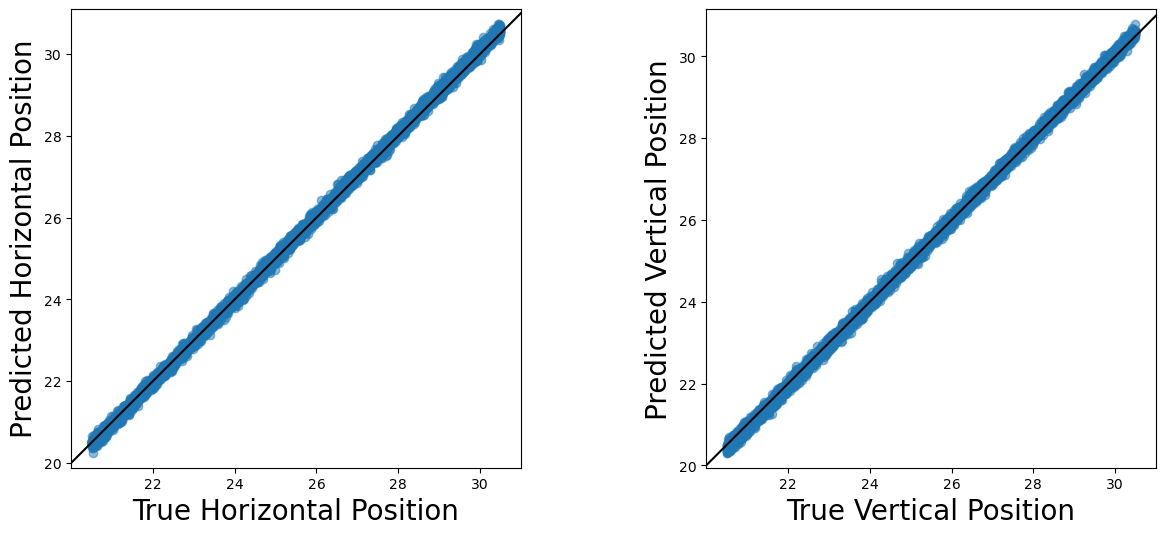

In [305]:
lodestar_predictions = lodestar.pooled(images).detach().numpy()

plot_position_comparison(positions, lodestar_predictions)

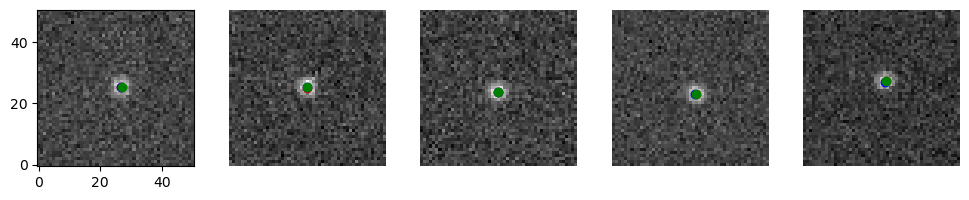

In [306]:
fig, axs = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axs):
    image, position = test_dataset[i]
    rot_pred = rot_predictions[i]
    flip_pred = flip_predictions[i]
    ax.imshow(image[0], cmap="gray", origin="lower")
    ax.scatter(position[1], position[0], c="r")
    ax.scatter(rot_pred[1], rot_pred[0], c="b")
    ax.scatter(flip_pred[1], flip_pred[0], c="g")
    if i != 0: ax.axis("off")
plt.tight_layout()
plt.show()